In [ ]:
# @title loading packages
!pip install lmfit
!pip install numdifftools
from lmfit import minimize, Parameters, Parameter, report_fit, Model

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import pandas as pd
import csv
from scipy.integrate import solve_ivp
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 5.8 MB/s eta 0:00:00


In [ ]:
# @title 1. Setting parameters
# Molar masses
MW_s = 60.05        # g/mol (acetate)
MW_x = 24.6         # g/mol (biomass) values is derived from average elemental composition from Roels (1980) https://analyticalsciencejournals.onlinelibrary.wiley.com/doi/10.1002/bit.260221202
MW_Pi = 94.97       # g/mol (orthophosphate)
MW_3HB = 104.1      # g/mol (3HB)

# defined parameters (units)
params = {
'qs_max_g' : 7.832, # theoretical maximum acetate uptake rate before phosphate starvation (mol/mol biomass/hour)
'qs_max_p' : 0.6513, # theoretical maximum acetate uptake rate after phosphate starvation (mol/mol biomass/hour)
'Ks1' : 0.07937, # half saturation constant for qs_max_g (mol/L)
'Ks2' : 0.05469, # half saturation constant for qs_max_p (mol/L)
'Y_xs_g' : 0.1105, # theoretical maximum biomass:acetate before phosphate starvation (mol biomass/mol)
'Y_xs_p' : 0.2284, # theoretical maximum biomass:acetate after phosphate starvation (mol biomass/mol)
'qpi_max' : 0.009627, # theoretical maximum phopshate uptake rate (mol/mol biomass/hour)
'Kpi' : 8.621e-06, # half saturation constant for qpi_max (mol/L)
'qp_max' : 0.1335, # theoretical maximum PHB production rate (mol/mol biomass/hour)
'Pi_threshold' : 6.539e-06, # phopshate level where phosphate starvation is achieved (mol/L)
'n' : 1, # hill coefficient for phosphate-dependent PHB production
'Kp' : 0.07891, # half saturation constant for acetate-dependent PHB production (mol/L)
'm' : 3.004, # hill coefficient for phosphate-dependent PHB production
'Pi_min' : 1.6e-06, # offset value for phosphate level that assumed as background value (mol/L)
'cs_threshold' : 1e-06, # an arbitrary value that stop PHB production if acetate goes beyond this value during prediction (mol/L)
'cs_min' : 0.00017, # offset value for acetate level that assumed as background value (mol/L)
'Kxpi' : 0.002499, # half saturation constant for phosphate-biomass:acetate yield (mol/L)
'Ks_pi' : 1.555e-05, # half saturation constant for phosphate-biomass:acetate yield (mol/L)
  }

# setting parameters for initial time (t0), timestep (dt), and end time of simulation (t_end)
t0, dt, t_end = 0, 0.01, 25
t_span = (t0, t_end)
t_eval = np.arange(t0, t_end + dt, dt)

# number of steps allowed for the underlying solver when using the Levenberg-Marquardt method
mxstep = 500000000

In [ ]:
# @title 2. Define ODE function
def batch_ode(c, t, params):

    qs_g_max = params['qs_max_g']
    qs_p_max = params['qs_max_p']
    Ks1 = params['Ks1']
    Ks2 = params['Ks2']
    Yxs_g_max = params['Y_xs_g']
    Yxs_p_max = params['Y_xs_p']
    Pi_threshold = params['Pi_threshold']
    qp_max = params['qp_max']
    n = params['n']
    qpi_max = params['qpi_max']
    Kpi = params['Kpi']
    qp_max = params['qp_max']
    m = params['m']
    Pi_min = params['Pi_min']
    cs_min = params['cs_min']
    Kp = params['Kp']
    cs_threshold = params['cs_threshold']
    Kxpi = params['Kxpi']
    Ks_pi = params['Ks_pi']

    cs, cx, Pi, PHB = c

    # Effective Phosphate and acetate (adding offset for dataset)
    Pi = max(Pi - Pi_min, 0)
    cs = max(cs - cs_min, 0)

    # Pi-dependent binary switch for acetate uptake (growth phase -> production phase)
    Pi_avail = 0 if Pi < Pi_threshold else Pi / (1e-12 + Pi)

    # acetate uptake
    qs_g = qs_g_max * (cs / (Ks1 + cs)) * Pi_avail
    qs_p = qs_p_max * (cs / (Ks2 + cs)) * (1 - Pi_avail)
    qs = max(qs_g + qs_p, 0)

    # biomass growth
    Yxs = Yxs_g_max * (Pi / Kxpi + Pi) + Yxs_p_max
    mu = max(qs * Yxs, 0)

    # PHB production
    lim_Pi = Pi_threshold**n / (Pi_threshold**n + Pi**n) # sigmodal-dependency on Phosphate
    lim_cs = cs**m / (Kp**m + cs**m)  # sigmoidal-dependency on acetate
    qp = qp_max * lim_Pi * lim_cs

    # Pi uptake
    cs_avail = 0 if cs < cs_threshold else cs / (Ks_pi + cs)
    qpi = qpi_max * cs_avail * (Pi/ (Kpi + Pi))
    qpi = max(qpi, 0)

    # Differential equations
    d_cs = -qs * cx - qp * cx
    d_cx = mu * cx
    d_Pi = -qpi * cx
    d_PHB = qp * cx

    return [d_cs, d_cx, d_Pi, d_PHB]

In [ ]:
# @title Set initial conditions
# cs = acetate; cx = biomass; Pi = phosphate; PHB = PHB
# all variables are in mol/L

# high Pi group (1.32mM)
cs0_0 = 0.0590                   # mol/L
cx0_0 = 0.00303 / MW_x        # mol/L
Pi0_0 = 1.11 / 1000           # mol/L
PHB0_0 = 0.000407 / MW_3HB                   # mol/L

cs0_1 = 0.0726                  # mol/L
cx0_1 = 0.00229 / MW_x          # mol/L
Pi0_1 = 0.1036 / 1000           # mol/L
PHB0_1 = 0.000814 / MW_3HB                   # mol/L

# new attempt (0.0132mM Pi)
cs0_2 = 0.0654           # mol/L
cx0_2 = 0.00283 / MW_x          # mol/L
Pi0_2 = 0.0102 / 1000           # mol/L
PHB0_2 = 0.000745 / MW_3HB      # mol/L

# putting variable in a list
y0_0 = [cs0_0, cx0_0, Pi0_0, PHB0_0]
y0_1 = [cs0_1, cx0_1, Pi0_1, PHB0_1]
y0_2 = [cs0_2, cx0_2, Pi0_2, PHB0_2]

# concatenate every experimental group in a list
y0_list = [y0_0, y0_1, y0_2]


In [ ]:
# @title 3. Define Specific Residual Function
def multi_experiment_residual_specific(params, t_list, data_list, y0_list, sigma_list=None):
    combined_residuals = []
    for i in range(len(data_list)):
        t_current = t_list[i]
        data_current = data_list[i]
        y0_current = y0_list[i]
        sigma_current = sigma_list[i] if sigma_list is not None else 1.0

        temp_params = params.copy()

        model_output = odeint(batch_ode, y0_current, t_current, args=(temp_params,), mxstep=mxstep)
        res_current = (model_output - data_current) / sigma_current
        combined_residuals.append(res_current.ravel())

    return np.concatenate(combined_residuals)

In [ ]:
# @title Data managing
# ID = 'ID'(as triplicate at the same timepoint in csv file)

# mean values
X_COL = 'time'      # time
Y1 = 'ace_mm'       # acetate
Y2 = 'pi_mm'        # (phosphate)
Y3 = 'biom_gl'      # (biomass)
Y4 = 'phb_gl'       # (PHB)

# standard deviation
Yerr1 = 'ace_sd'    # acetate
Yerr2 = 'pi_sd'     # phosphate
Yerr3 = 'biom_sd'   # biomass
Yerr4 = 'phb_sd'    # PHB

# uploading data csv
CSV_PATH0 = "/content/p0_mean_newpi_all_0.1SD_opt.csv"
CSV_PATH1 = "/content/p1_mean_all_0.1SD_opt.csv"
CSV_PATH2 = "/content/p2_mean_2nd_attempt_all_0.1SD_opt.csv"

# reading csv file
df0 = pd.read_csv(CSV_PATH0)
df1 = pd.read_csv(CSV_PATH1)
df2 = pd.read_csv(CSV_PATH2)

# Combine into (N, 4) matrix with corrected order: cs, cx, Pi, PHB and convert everything to mol/L
data_measured0 = np.column_stack((
    df0[Y1].to_numpy(dtype=float) / 1000,
    df0[Y3].to_numpy(dtype=float) / MW_x,
    df0[Y2].to_numpy(dtype=float) / 1000,
    df0[Y4].to_numpy(dtype=float) / MW_3HB
))

data_measured1 = np.column_stack((
    df1[Y1].to_numpy(dtype=float) / 1000,
    df1[Y3].to_numpy(dtype=float) / MW_x,
    df1[Y2].to_numpy(dtype=float) / 1000,
    df1[Y4].to_numpy(dtype=float) / MW_3HB
))

data_measured2 = np.column_stack((
    df2[Y1].to_numpy(dtype=float) / 1000,
    df2[Y3].to_numpy(dtype=float) / MW_x,
    df2[Y2].to_numpy(dtype=float) / 1000,
    df2[Y4].to_numpy(dtype=float) / MW_3HB
))

# Combine SD into (N, 4) matrix with corrected order: cs, cx, Pi, PHB and convert everything to mol/L
sigma_measured0 = np.column_stack((
    df0[Yerr1].to_numpy(dtype=float) / 1000,
    df0[Yerr3].to_numpy(dtype=float) / MW_x,
    df0[Yerr2].to_numpy(dtype=float) / 1000,
    df0[Yerr4].to_numpy(dtype=float) / MW_3HB
))

sigma_measured1 = np.column_stack((
    df1[Yerr1].to_numpy(dtype=float) / 1000,
    df1[Yerr3].to_numpy(dtype=float) / MW_x,
    df1[Yerr2].to_numpy(dtype=float) / 1000,
    df1[Yerr4].to_numpy(dtype=float) / MW_3HB
))

sigma_measured2 = np.column_stack((
    df2[Yerr1].to_numpy(dtype=float) / 1000,
    df2[Yerr3].to_numpy(dtype=float) / MW_x,
    df2[Yerr2].to_numpy(dtype=float) / 1000,
    df2[Yerr4].to_numpy(dtype=float) / MW_3HB
))

# 1. Organize Time vectors (List of 1D arrays)
t_list = [
    df0[X_COL].to_numpy(dtype=float),
    df1[X_COL].to_numpy(dtype=float),
    df2[X_COL].to_numpy(dtype=float)
]

# 2. Organize Observed Data (List of (N,4) arrays)
data_list = [
    data_measured0, # Shape (N1, 4)
    data_measured1, # Shape (N2, 4)
    data_measured2  # Shape (N3, 4)
]

# 3. Organize SD (List of (N,4) arrays)
sigma_list = [
    sigma_measured0,
    sigma_measured1,
    sigma_measured2
]

In [ ]:
# @title 6. Configure Parameters
fit_params = Parameters()

# Initialize from global params
for key, value in params.items():
    fit_params.add(key, value=value, vary=True , max = 10.0 , min = 1e-6)

# # biomass growth
fit_params['Y_xs_g'].set(vary=True, min=0.0, max=2.0)
fit_params['Y_xs_p'].set(vary=True, min=0.0, max=2.0)

# hill coefficients
fit_params['n'].set(vary=True, min=1.0, max=5.0)
fit_params['m'].set(vary=True, min=1.0, max=5.0)

# offset values are fixed
fit_params['Pi_min'].set(vary=False)
fit_params['cs_threshold'].set(vary=False)
fit_params['cs_min'].set(vary=False)


In [ ]:
# @title 7. Optimizing

# Fit model
result = minimize(
    multi_experiment_residual_specific,
    fit_params,
    args=(t_list, data_list, y0_list, sigma_list),
    nan_policy = 'omit',
    method='leastsq' # 'leastsq' is often faster/more robust for simple fitting
)
report_fit(result)

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 22
    # data points      = 82
    # variables        = 15
    chi-square         = 320.354516
    reduced chi-square = 4.78141069
    Akaike info crit   = 141.742138
    Bayesian info crit = 177.842927
[[Variables]]
    qs_max_g:      7.83200000 +/- 0.75587058 (9.65%) (init = 7.832)
    qs_max_p:      0.65130000 +/- 0.53999714 (82.91%) (init = 0.6513)
    Ks1:           0.07937000 +/- 0.00157082 (1.98%) (init = 0.07937)
    Ks2:           0.05469000 +/- 0.06329451 (115.73%) (init = 0.05469)
    Y_xs_g:        0.11050000 +/- 0.02719697 (24.61%) (init = 0.1105)
    Y_xs_p:        0.22840000 +/- 0.02067217 (9.05%) (init = 0.2284)
    Kpi:           8.6210e-06 +/- 4.0569e-06 (47.06%) (init = 8.621e-06)
    qpi_max:       0.00962700 +/- 8.6663e-04 (9.00%) (init = 0.009627)
    qp_max:        0.13350000 +/- 0.05466039 (40.94%) (init = 0.1335)
    Pi_threshold:  6.5390e-06 +/- 7.6506e-07 (11.70%) (init = 6.539e-06)


Chi-square value: 320.3545
reduced Chi-square value: 4.7814
Note: parameter boundary is fixed


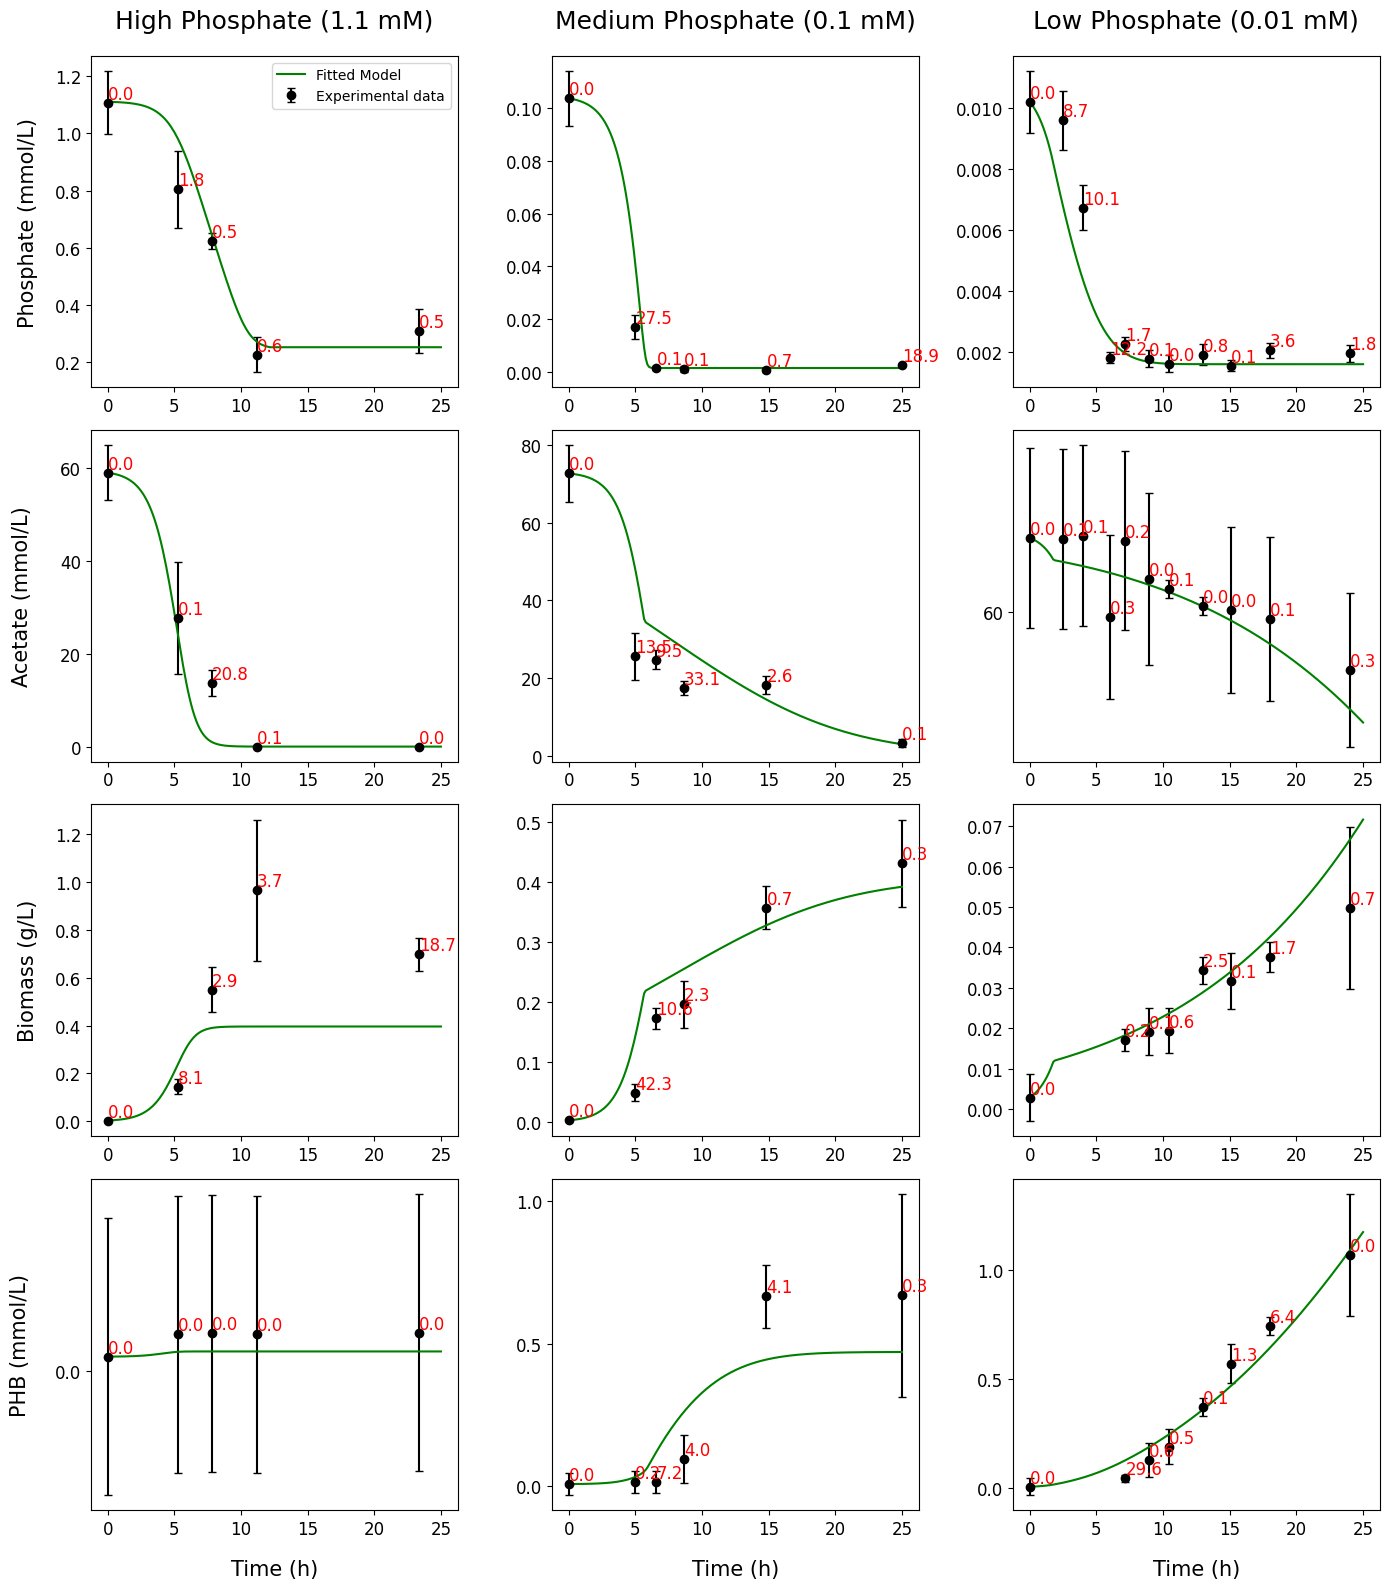

In [ ]:
# @title 8. Plotting result for preview (with chi-square value contributed at each point)
import matplotlib.ticker as ticker

# Generate plots for all 3 experiments
# Layout: 4 Rows (Metabolites) x 3 Columns (Experiments)
fig, axs = plt.subplots(4, 3, figsize=(14, 16))

# New variable names with updated units
var_names = ['Acetate (mmol/L)', 'Biomass (g/L)', 'Phosphate (mmol/L)', 'PHB (mmol/L)']

# Scaling factors (from M to new units)
# 0: Acetate (M -> mM), 1: Biomass (M -> g/L), 2: Pi (M -> mM), 3: PHB (M -> mM)
scaling_factors = {
    0: 1000,
    1: MW_x, # 24.6 g/mol
    2: 1000,
    3: 1000
}

# Custom Column Titles for Experiments
exp_titles = ["High Phosphate (1.1 mM)", "Medium Phosphate (0.1 mM)", "Low Phosphate (0.01 mM)"]

# Define the desired plotting order of variables (indices)
plot_order_indices = [2, 0, 1, 3]

# Custom Tick Intervals for Linear Plots (in NEW UNITS)
custom_ticks = {
    0: 20,    # Acetate: Every 20 mM
    3: 0.5    # PHB: Every 0.5 mM
}

subtitle_font_size = 18
axes_font_size = 15
tick_label_size = 12

# Use a smooth continuous time vector for plotting (0 to 25h)
t_eval1 = np.linspace(0, 25, 200)

# Custom Formatter for Log Plots (1e-2 style)
def log_tick_formatter(val, pos=None):
    return f"{val:.0e}".replace("e-00", "e-0").replace("e+00", "e+0")

for i in range(len(y0_list)):
    # Prepare parameters for this specific experiment
    sim_params = result.params.copy()

    # Simulate
    t_eval = t_list[i]
    y0 = y0_list[i]
    sim_data1 = odeint(batch_ode, y0, t_eval1, args=(sim_params,), mxstep=mxstep)
    sim_data = odeint(batch_ode, y0, t_eval, args=(sim_params,), mxstep=mxstep)

    # Plot for each row (k corresponds to the visual row index)
    for k, var_idx in enumerate(plot_order_indices):
        ax = axs[k, i] # Row: Visual Row k, Col: Experiment i

        # var_idx is the actual data index (0, 1, 2, or 3)
        scale = scaling_factors[var_idx]

        # Extract valid data (ignore NaNs) and SCALE
        valid_mask = ~np.isnan(data_list[i][:, var_idx])
        t_valid = t_eval[valid_mask]
        data_valid = data_list[i][valid_mask, var_idx] * scale
        sigma_valid = sigma_list[i][valid_mask, var_idx] * scale
        sim_valid = sim_data[valid_mask, var_idx] * scale

        # Measured datapoint (scatter)
        ax.errorbar(t_valid, data_valid, yerr=sigma_valid,
                    fmt='o', color='black', label='Experimental data', capsize=3)
        # Fitted curve (scaled)
        ax.plot(t_eval1, sim_data1[:, var_idx] * scale, color='green', label='Fitted Model')

        # # Apply custom y-limits if defined
        # if var_idx in custom_ylim:
        #     ax.set_ylim(custom_ylim[var_idx])

        # Apply Custom Ticks to Linear Plots
        if var_idx in custom_ticks:
            ax.yaxis.set_major_locator(ticker.MultipleLocator(custom_ticks[var_idx]))

        # Set titles and labels with custom font sizes and padding
        # Column headers (Experiments)
        if k == 0:
            ax.set_title(exp_titles[i], fontsize=subtitle_font_size, pad=20)

        # Row labels (Metabolites)
        if i == 0:
            # Add extra padding for Acetate (var_idx 0) to align with others
            pad = 20 if var_idx == 0 else 12
            if var_idx == 3: # PHB
                 pad = 18
            ax.set_ylabel(var_names[var_idx], fontsize=axes_font_size, labelpad=pad)

        # Bottom X-axis label
        if k == 3:
            ax.set_xlabel('Time (h)', fontsize=axes_font_size, labelpad=15)

        # Calculate and annotate Chi-square contributions
        chi2_contribs = ((sim_valid - data_valid) / sigma_valid)**2

        # Include chi2_contribs in zip so we can unpack 'c2'
        for tx, yx, c2 in zip(t_valid, data_valid, chi2_contribs):
            # Annotate with the Chi-square value
            ax.text(tx, yx, f'{c2:.1f}', fontsize=12, color='red',
                    va='bottom', ha='left')

        # Customize tick params
        ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

        if i == 0 and k == 0:
            ax.legend()

print(f"Chi-square value: {result.chisqr:.4f}")
print(f"reduced Chi-square value: {result.redchi:.4f}")

print("Note: parameter boundary is fixed")

plt.style.use('default')
plt.tight_layout()
plt.show()

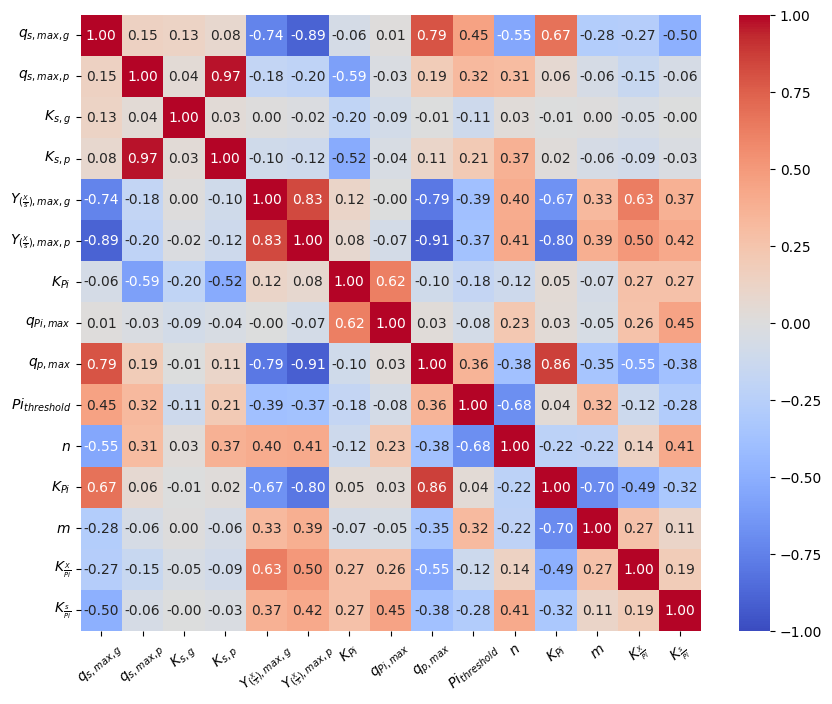

In [ ]:
# @title 9. Plotting correlation heatmap between optimized parameters
if 'result' in locals() and result.covar is not None:
    # Extract variable names and covariance matrix
    var_names = result.var_names
    covar = result.covar

    # Define a mapping to rename variables for the plot.
    # Change the string values on the right to rename the parameters on the heatmap.
    name_mapping = {name: name for name in var_names}
    name_mapping['qs_max_g'] = r'$q_{s,max,g}$'
    name_mapping['qs_max_p'] = r'$q_{s,max,p}$'
    name_mapping['Ks1'] = r'$K_{s,g}$'
    name_mapping['Ks2'] = r'$K_{s,p}$'
    name_mapping['Y_xs_g'] = r'$Y_{(\frac{X}{s}),max,g}$'
    name_mapping['Y_xs_p'] = r'$Y_{(\frac{X}{s}),max,p}$'
    name_mapping['Pi_threshold'] = r'$Pi_{threshold}$'
    name_mapping['qp_max'] = r'$q_{p,max}$'
    name_mapping['n'] = r'$n$'
    name_mapping['m'] = r'$m$'
    name_mapping['Kp'] = r'$K_{Pi}$'
    name_mapping['Kxpi'] = r'$K_{\frac{X}{Pi}}$'
    name_mapping['Ks_pi'] = r'$K_{\frac{s}{Pi}}$'
    name_mapping['qpi_max'] = r'$q_{Pi,max}$'
    name_mapping['Kpi'] = r'$K_{Pi}$'


    display_names = [name_mapping.get(name, name) for name in var_names]

    # Calculate Correlation Matrix from Covariance Matrix
    # corr(i, j) = cov(i, j) / (sigma_i * sigma_j)
    sigma = np.sqrt(np.diag(covar))
    corr_matrix = covar / np.outer(sigma, sigma)

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1,
                xticklabels=display_names, yticklabels=display_names)
    plt.xticks(rotation=40, ha='center')
    plt.title('')
    plt.savefig('heatmap.svg')
    plt.show()
else:
    print("No fit result found or covariance matrix is missing. Make sure to run the fitting cell first.")